Quiz 2

Setup

In [11]:
# load datasets
im  <- read.csv("InfantMortality.csv")
sat <- read.csv("SATGPA.csv")
# check variable names
names(im); names(sat)
head(im)

[1] "Mortality" "Year"

[1] "MathSAT"   "VerbalSAT" "GPA"

,Mortality,Year
,<dbl>,<int>
1,85.8,1920
2,64.6,1930
3,47.0,1940
4,29.2,1950
5,26.0,1960
6,20.0,1970


1(a)

Mortality ~ Year   R^2 = 0.8888 
log(Mortality) ~ Year   R^2 = 0.9935 
Mortality ~ log(Year)   R^2 = 0.8922 
log(Mortality) ~ log(Year)   R^2 = 0.9934 


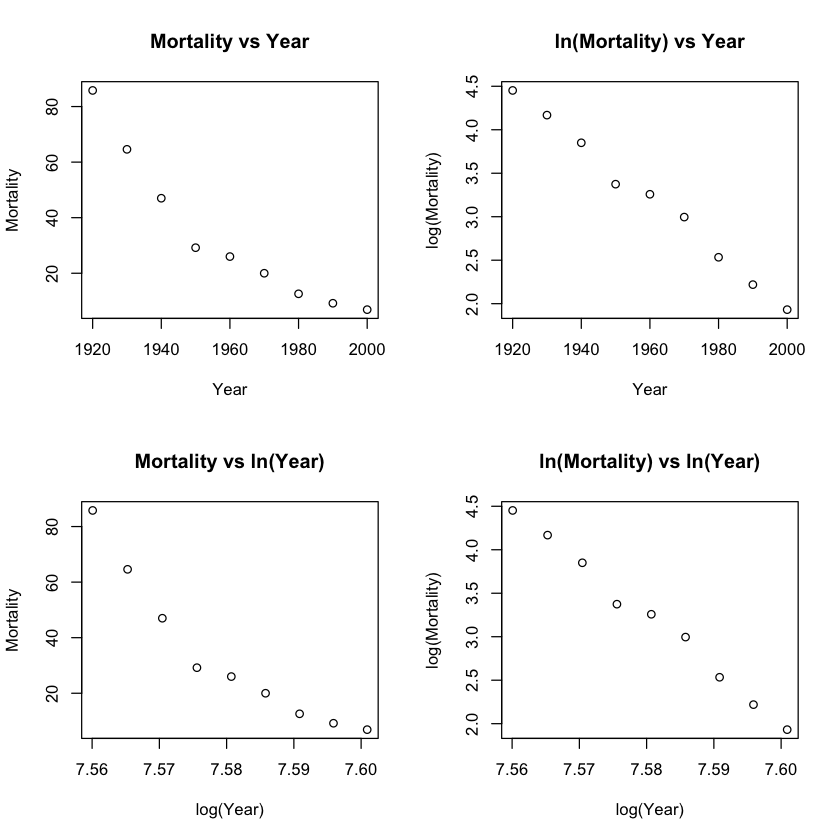

In [13]:
# plot and fit raw, ln and log-log versions,
# compare R^2 value (which best linearizes the data)
par(mfrow = c(2, 2))
plot(Mortality ~ Year,           data = im, main = "Mortality vs Year")
plot(log(Mortality) ~ Year,      data = im, main = "ln(Mortality) vs Year")
plot(Mortality ~ log(Year),      data = im, main = "Mortality vs ln(Year)")
plot(log(Mortality) ~ log(Year), data = im, main = "ln(Mortality) vs ln(Year)")
par(mfrow = c(1, 1))

forms <- list(Mortality ~ Year, log(Mortality) ~ Year,
              Mortality ~ log(Year), log(Mortality) ~ log(Year))
for (f in forms) {
  cat(deparse(f), "  R^2 =", round(summary(lm(f, data = im))$r.squared, 4), "\n")
}

1


Call:
lm(formula = log(Mortality) ~ Year, data = im)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.139593 -0.031867 -0.003877  0.023107  0.113316 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 65.0699354  1.8910455   34.41 4.54e-09 ***
Year        -0.0315673  0.0009647  -32.72 6.44e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.07473 on 7 degrees of freedom
Multiple R-squared:  0.9935,	Adjusted R-squared:  0.9926 
F-statistic:  1071 on 1 and 7 DF,  p-value: 6.444e-09


ln(Mortality)-hat = 65.0699 + (-0.03157) * Year


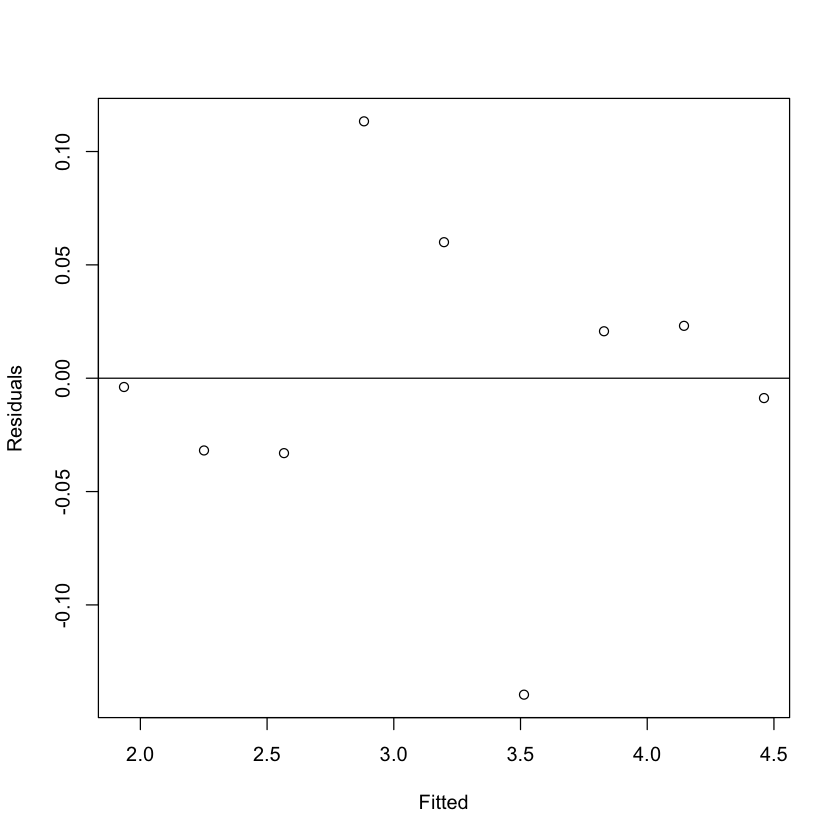

In [15]:
# fitted line and LSE with residual plot to check fit
m1 <- lm(log(Mortality) ~ Year, data = im)
summary(m1)

b <- coef(m1)
cat(sprintf("ln(Mortality)-hat = %.4f + (%.5f) * Year\n", b[1], b[2]))

plot(fitted(m1), resid(m1), xlab = "Fitted", ylab = "Residuals")
abline(h = 0)

1(b)

In [16]:
# prediction for 2009
pred_ln <- predict(m1, data.frame(Year = 2009))
pred_ln
exp(pred_ln)   # back-transform: deaths per 100,000 infants

1 
1.651293

1 
5.213716

Problem 2


	Pearson's product-moment correlation

data:  sat$VerbalSAT and sat$GPA
t = 1.1825, df = 22, p-value = 0.2496
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1763308  0.5896995
sample estimates:
      cor 
0.2444543 



Call:
lm(formula = GPA ~ VerbalSAT, data = sat)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.62002 -0.25932  0.03885  0.20502  0.51621 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.6042036  0.4377919   5.948  5.5e-06 ***
VerbalSAT   0.0009056  0.0007659   1.182     0.25    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3154 on 22 degrees of freedom
Multiple R-squared:  0.05976,	Adjusted R-squared:  0.01702 
F-statistic: 1.398 on 1 and 22 DF,  p-value: 0.2496


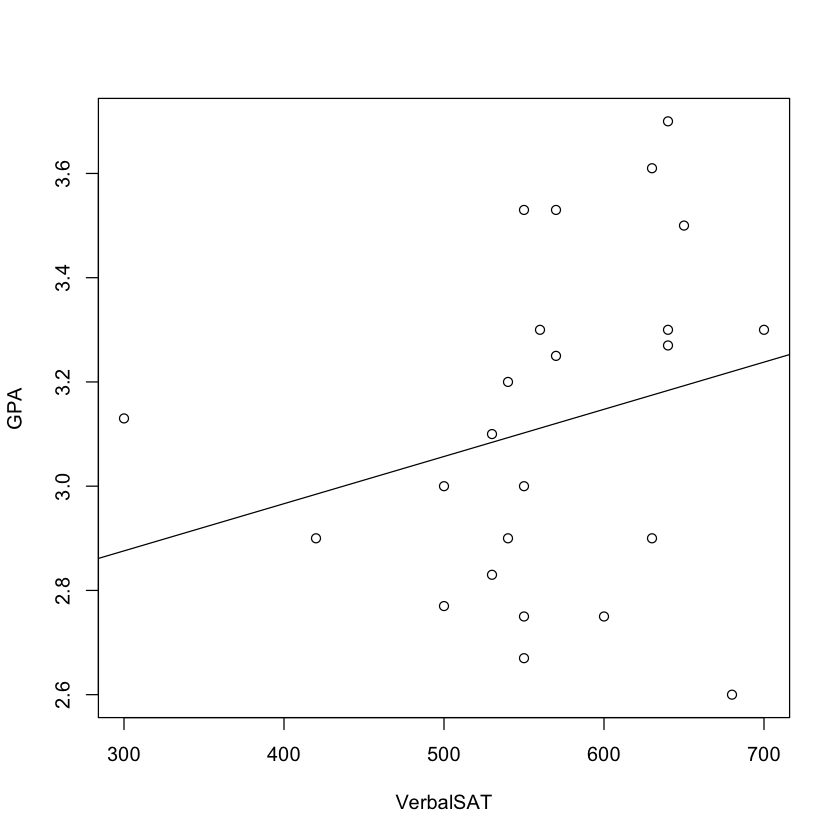

In [17]:
# runs t-test for correlation and confirms it with the slope test to get:
# r, t statistic, and p-value for the conclusion
cor.test(sat$VerbalSAT, sat$GPA)      # r, t, df, P-value

m2 <- lm(GPA ~ VerbalSAT, data = sat)
summary(m2)                           # same t and P for the slope

plot(GPA ~ VerbalSAT, data = sat)
abline(m2)


	Pearson's product-moment correlation

data:  sat$VerbalSAT and sat$GPA
t = 1.1825, df = 22, p-value = 0.2496
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1763308  0.5896995
sample estimates:
      cor 
0.2444543 



Call:
lm(formula = GPA ~ VerbalSAT, data = sat)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.62002 -0.25932  0.03885  0.20502  0.51621 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.6042036  0.4377919   5.948  5.5e-06 ***
VerbalSAT   0.0009056  0.0007659   1.182     0.25    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3154 on 22 degrees of freedom
Multiple R-squared:  0.05976,	Adjusted R-squared:  0.01702 
F-statistic: 1.398 on 1 and 22 DF,  p-value: 0.2496


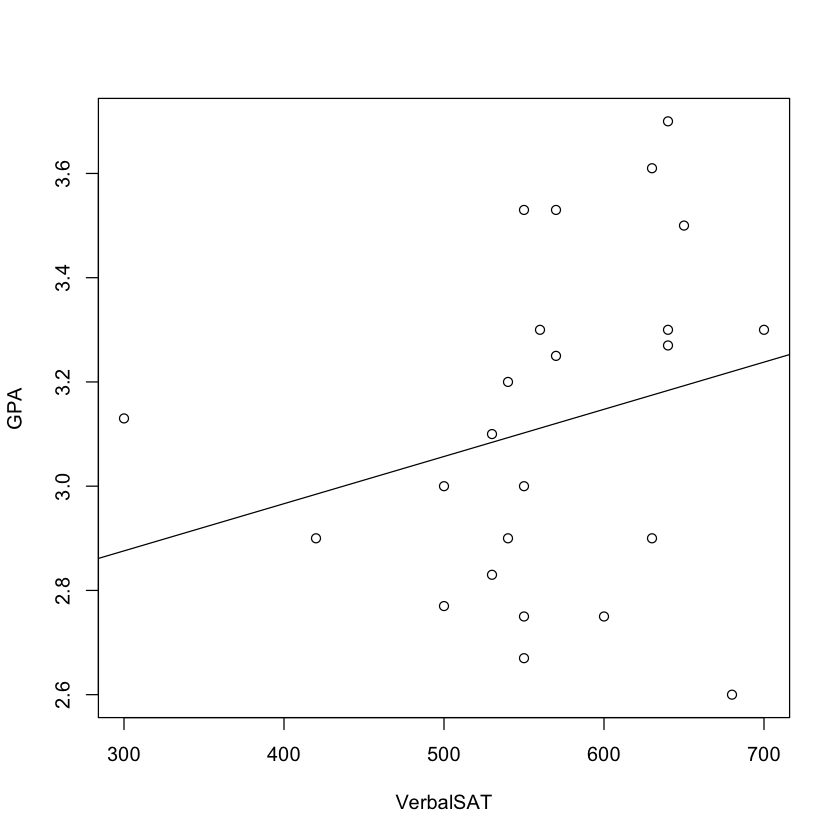

In [6]:
cor.test(sat$VerbalSAT, sat$GPA)      # r, t, df, P-value

m2 <- lm(GPA ~ VerbalSAT, data = sat)
summary(m2)                           # same t and P for the slope

plot(GPA ~ VerbalSAT, data = sat)
abline(m2)

3(b)

In [18]:
# builds interval for population slope of elevation
# df = 70
tstar <- qt(0.95, df = 72 - 2)
tstar
1.9195 + c(-1, 1) * tstar * 0.6253    # approx (0.877, 2.962)

[1] 1.666914

[1] 0.8771784 2.9618216

Bonus

In [20]:
# numerically check that
# slope t-test and correlation t-test give the same statistic
summary(m2)$coefficients["VerbalSAT", "t value"]   # slope t
cor.test(sat$VerbalSAT, sat$GPA)$statistic         # correlation t (should match)

# Problem 3 sanity check: r from R^2 = 0.119, n = 72
r3 <- sqrt(0.119)
r3 * sqrt(70) / sqrt(1 - r3^2)                     # about 3.07

[1] 1.182467

t 
1.182467

[1] 3.074925